In [250]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [251]:
df = pd.read_csv("Product-Demand-Inventory-Analytics-Dataset.csv")

In [252]:
df

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
0,TBOX,TBOX,Berkeley,94701,27/08/2018,23:56:00,1000,504.010
1,Worksuite 1000,Tribes,Berkeley,94701,18/07/2018,23:55:00,1000,147.330
2,TBOX,TBOX S3,Berkeley,94701,14/09/2018,23:50:00,1000,185.250
3,Worksuite 1000,Sociplace,Berkeley,94701,05/10/2018,23:45:00,1000,255.000
4,TBOX,TBOX S3,Berkeley,94701,15/06/2018,23:35:00,1000,185.250
...,...,...,...,...,...,...,...,...
49995,Worksuite 1000,ShareIt,Berkeley,94701,15/02/2019,20:33:00,1,197.110
49996,Worksuite 1000,SlidePoint,Berkeley,94701,22/07/2019,15:45:00,1,364.390
49997,Worksuite 1000,DoneIt,Berkeley,94701,04/07/2019,14:20:00,1,63.260
49998,Worksuite 1000,Streamer,Berkeley,94701,24/05/2018,16:30:00,1,256.554


In [253]:
df.head()

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
0,TBOX,TBOX,Berkeley,94701,27/08/2018,23:56:00,1000,504.01
1,Worksuite 1000,Tribes,Berkeley,94701,18/07/2018,23:55:00,1000,147.33
2,TBOX,TBOX S3,Berkeley,94701,14/09/2018,23:50:00,1000,185.25
3,Worksuite 1000,Sociplace,Berkeley,94701,05/10/2018,23:45:00,1000,255.00
4,TBOX,TBOX S3,Berkeley,94701,15/06/2018,23:35:00,1000,185.25


In [254]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Category      50000 non-null  str    
 1   Product       50000 non-null  str    
 2   Warehouse     50000 non-null  str    
 3   Zip           50000 non-null  int64  
 4   Date          50000 non-null  str    
 5   Time          50000 non-null  str    
 6   Order Demand  50000 non-null  int64  
 7   Value         50000 non-null  float64
dtypes: float64(1), int64(2), str(5)
memory usage: 3.1 MB


In [255]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

In [256]:
df[df.duplicated(keep=False)]

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
2,TBOX,TBOX S3,Berkeley,94701,2018-09-14,23:50:00,1000,185.25
3,Worksuite 1000,Sociplace,Berkeley,94701,2018-10-05,23:45:00,1000,255.00
5,Worksuite 1000,SlidePoint,Berkeley,94701,2018-07-18,23:55:00,1000,364.39
7,Worksuite 1000,Whathype,Berkeley,94701,2018-08-20,23:30:00,1000,396.33
8,Worksuite 1000,EmailOut,Berkeley,94701,2018-07-26,23:30:00,1000,91.09
...,...,...,...,...,...,...,...,...
49991,TBOX,TBOX,Berkeley,94701,2019-07-19,14:00:00,1,504.01
49993,Worksuite 1000,Wordwrite,Berkeley,94701,2019-10-04,11:00:00,1,467.22
49994,BI Stack,BI Visualiser,Berkeley,94701,2018-06-25,22:45:00,1,128.54
49995,Worksuite 1000,ShareIt,Berkeley,94701,2019-02-15,20:33:00,1,197.11


In [257]:
df.isna().sum()


Category        0
Product         0
Warehouse       0
Zip             0
Date            0
Time            0
Order Demand    0
Value           0
dtype: int64

In [258]:
df.dtypes

Category                   str
Product                    str
Warehouse                  str
Zip                      int64
Date            datetime64[us]
Time                       str
Order Demand             int64
Value                  float64
dtype: object

In [259]:
df["Time"].head()

0    23:56:00
1    23:55:00
2    23:50:00
3    23:45:00
4    23:35:00
Name: Time, dtype: str

In [260]:
df[df["Date"].dt.year == 2019]

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value
694,Worksuite 1000,SlidePoint,Berkeley,94701,2019-02-12,21:00:00,1000,364.39
697,Worksuite 1000,VideoRight,Berkeley,94701,2019-02-04,21:00:00,1000,601.56
698,BI Stack,BI Visualiser,Berkeley,94701,2019-01-15,21:00:00,1000,128.54
701,Worksuite 1000,PublishIt,Berkeley,94701,2019-01-22,21:00:00,1000,621.87
702,TBOX,TBOX,Berkeley,94701,2019-01-17,21:00:00,1000,504.01
...,...,...,...,...,...,...,...,...
49993,Worksuite 1000,Wordwrite,Berkeley,94701,2019-10-04,11:00:00,1,467.22
49995,Worksuite 1000,ShareIt,Berkeley,94701,2019-02-15,20:33:00,1,197.11
49996,Worksuite 1000,SlidePoint,Berkeley,94701,2019-07-22,15:45:00,1,364.39
49997,Worksuite 1000,DoneIt,Berkeley,94701,2019-07-04,14:20:00,1,63.26


In [261]:
df["Category"].nunique()

3

In [262]:
# demand across time

In [263]:
df["Year"] = df["Date"].dt.year

yearly_demand = (
    df.groupby("Year")["Order Demand"]
      .sum()
      .reset_index()
)

print(yearly_demand)

   Year  Order Demand
0  2018    1038212810
1  2019     648948337


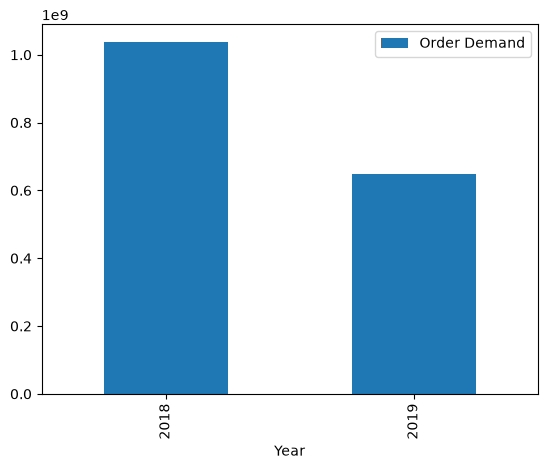

In [264]:
yearly_demand.plot.bar(
    x="Year",
    y="Order Demand"
)

plt.show()

In [265]:
df['Month'] = df["Date"].dt.month

In [266]:
df['Day_Name'] = df['Date'].dt.day_name()

In [272]:
df.head()

,Category,Product,Warehouse,Zip,Date,Time,Order Demand,Value,Year,Month,Day_Name
0,TBOX,TBOX,Berkeley,94701,2018-08-27,23:56:00,1000,504.01,2018,8,Monday
1,Worksuite 1000,Tribes,Berkeley,94701,2018-07-18,23:55:00,1000,147.33,2018,7,Wednesday
2,TBOX,TBOX S3,Berkeley,94701,2018-09-14,23:50:00,1000,185.25,2018,9,Friday
3,Worksuite 1000,Sociplace,Berkeley,94701,2018-10-05,23:45:00,1000,255.00,2018,10,Friday
4,TBOX,TBOX S3,Berkeley,94701,2018-06-15,23:35:00,1000,185.25,2018,6,Friday


In [273]:
day_counts = df['Day_Name'].value_counts()
print(day_counts)

Day_Name
Monday       10735
Tuesday      10041
Thursday     10009
Wednesday     9791
Friday        9424
Name: count, dtype: int64


In [270]:
average_demand_per_day

Day_Name
Friday       26428.535548
Monday       37644.773451
Thursday     28889.696373
Tuesday      37449.095508
Wednesday    37667.107139
Name: Order Demand, dtype: float64

In [277]:
# Group by Year and Month, then sum the Order Demand
monthly_trend = df.groupby(['Year', 'Month'])['Order Demand'].sum().reset_index()

# Sort chronologically to ensure the trend is in the correct time order
monthly_trend = monthly_trend.sort_values(by=['Year', 'Month'])

print(monthly_trend)

    Year  Month  Order Demand
0   2018      1      64286498
1   2018      2      47002549
2   2018      3      85131534
3   2018      4      35217745
4   2018      5      54664706
5   2018      6      58967703
6   2018      7      65649493
7   2018      8      72673304
8   2018      9     137021451
9   2018     10     277573292
10  2018     11      84650170
11  2018     12      55374365
12  2019      1      67079456
13  2019      2      57566533
14  2019      3      58482664
15  2019      4      66774707
16  2019      5      62472581
17  2019      6      66221261
18  2019      7      49639046
19  2019      8      50388017
20  2019      9      58004282
21  2019     10      42728461
22  2019     11      39734781
23  2019     12      29856548


<Figure size 1200x600 with 0 Axes>

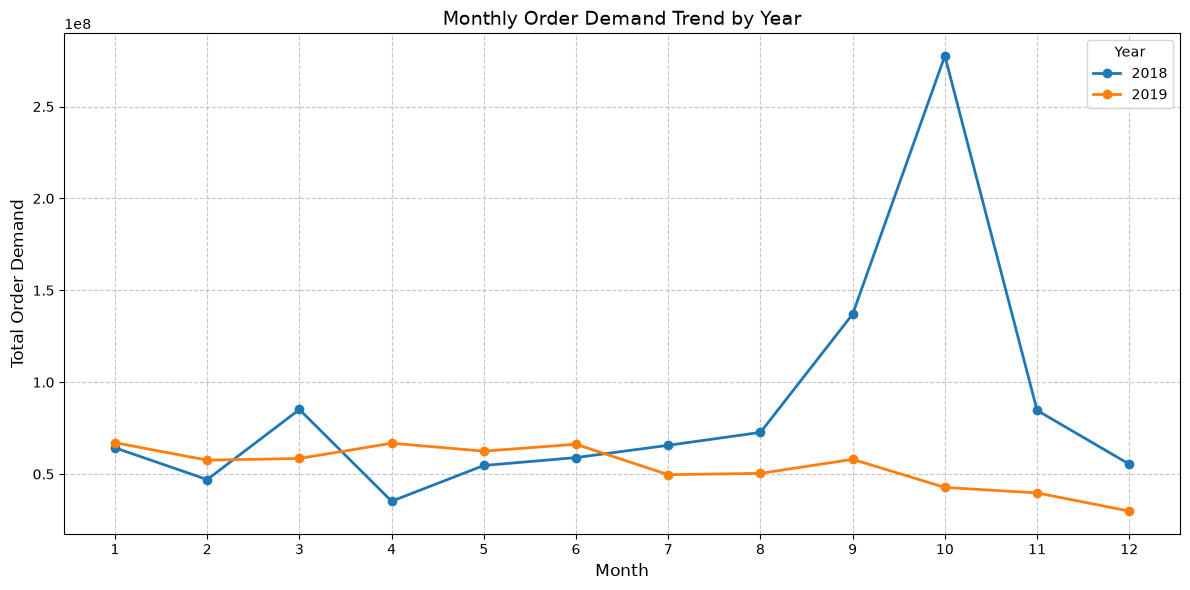

In [278]:
pivot_trend = monthly_trend.pivot(index='Month', columns='Year', values='Order Demand')

plt.figure(figsize=(12, 6))
pivot_trend.plot(kind='line', marker='o', linewidth=2, figsize=(12, 6))

plt.title('Monthly Order Demand Trend by Year', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Order Demand', fontsize=12)

plt.xticks(range(1, 13)) 
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

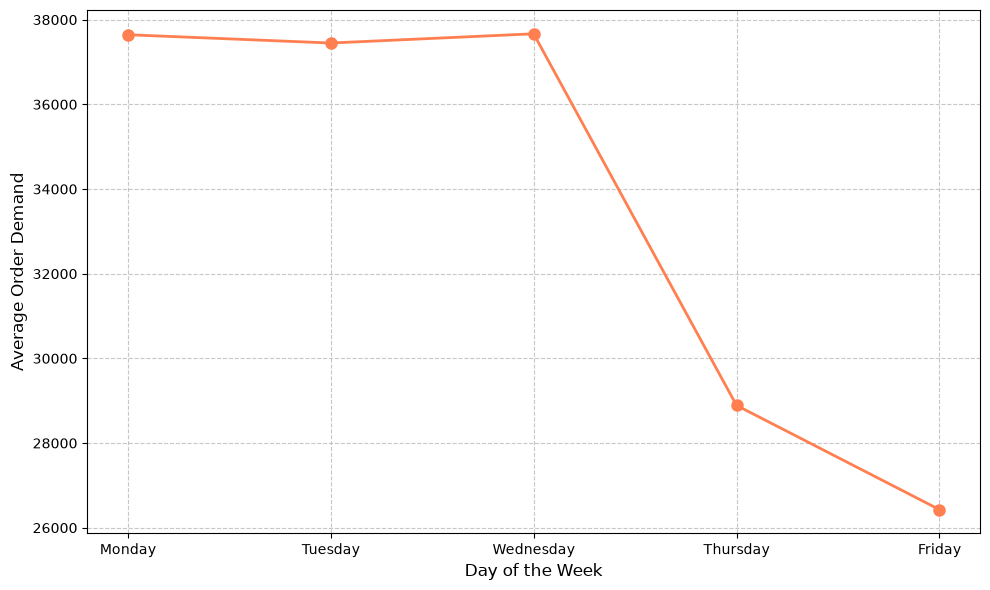

In [276]:
# Reorder the days 
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
average_demand_per_day = average_demand_per_day.reindex(day_order)

# Plot the data as a line graph with markers
plt.figure(figsize=(10, 6))
average_demand_per_day.plot(kind='line', marker='o', color='coral', linewidth=2, markersize=8)

plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Order Demand', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Added full grid for readability
plt.xticks(range(len(day_order)), day_order) # Ensures all days are labeled on the x-axis

plt.tight_layout()
plt.show()

In [78]:
# demand across region

In [187]:
df["WarehouseLabel"] = df["Zip"].astype(str) + " - " + df["Warehouse"].astype(str)

In [188]:
region_demand = (
    df.groupby("WarehouseLabel",as_index=True)["Order Demand"]
      .sum()
)
print(region_demand)

WarehouseLabel
17076 - Oakland Mills      31103792
24701 - Montcalm           56785681
78613 - Cedar Park       1246532479
94701 - Berkeley          352739195
Name: Order Demand, dtype: int64


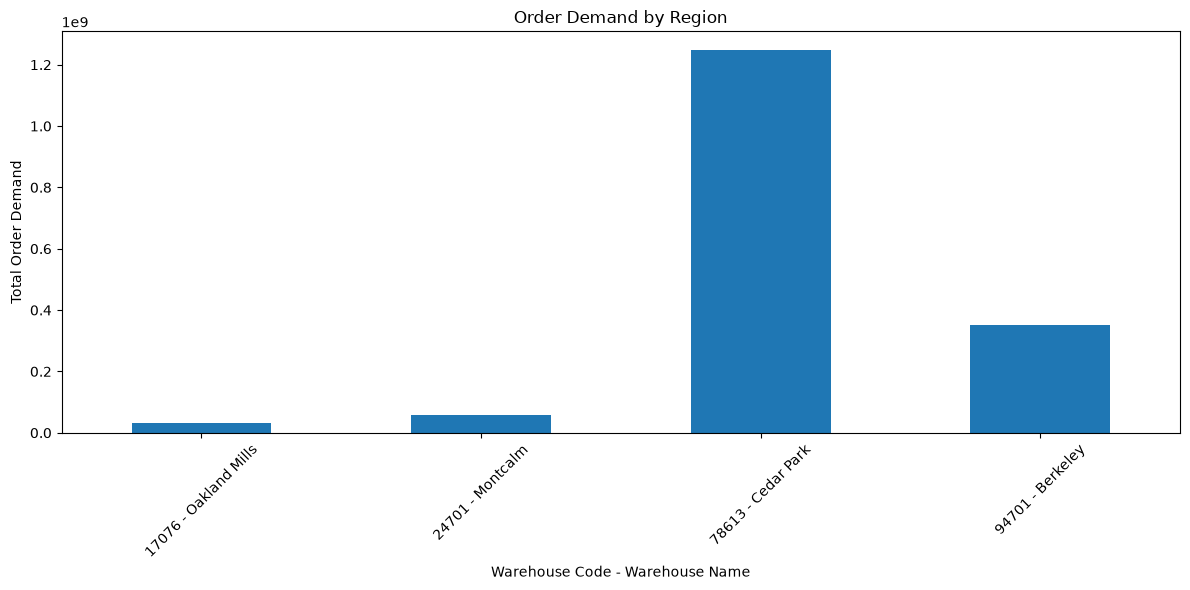

In [190]:
region_demand.plot(
      kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Order Demand by Region")
plt.xlabel("Warehouse Code - Warehouse Name")
plt.ylabel("Total Order Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
warehouse_demand = (
    df.groupby("Warehouse", as_index=True)["Order Demand"]
      .sum()
)
print(warehouse_demand)

Warehouse
Berkeley          352739195
Cedar Park       1246532479
Montcalm           56785681
Oakland Mills      31103792
Name: Order Demand, dtype: int64


In [147]:
# 78163 - Cedar Park warehouse fulfilled the highest order demand 

In [115]:
# demand by category

In [134]:
category_demand = (
    df.groupby("Category", as_index=True)["Order Demand"]
      .sum()
)
print(category_demand)

Category
BI Stack           189655699
TBOX               174340813
Worksuite 1000    1323164635
Name: Order Demand, dtype: int64


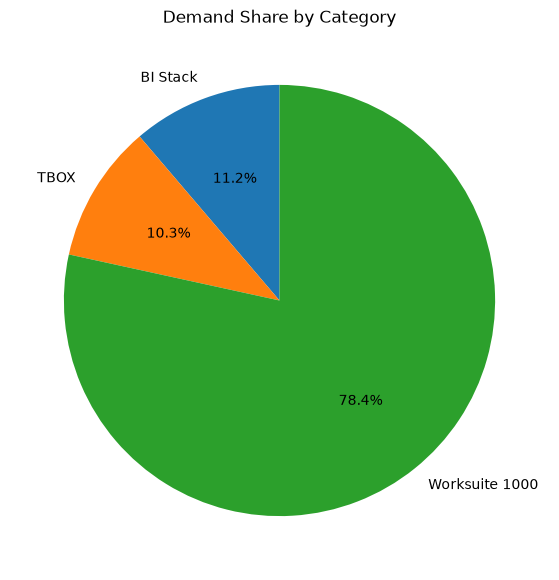

In [135]:
category_demand.plot.pie(
    y="Order Demand",
    figsize=(7, 7),
    autopct="%1.1f%%",
    startangle=90,
    legend=False
)

plt.title("Demand Share by Category")
plt.ylabel("")
plt.show()

In [84]:
# top-performing and underperforming products 

In [85]:
top_performing_products = (
    df.groupby("Product")["Order Demand"]
      .sum()
      .nlargest(10)
      .sort_values(ascending=False)
)
print(top_performing_products)

Product
TBOX             136830350
BI Visualiser    126114975
Sociplace        124695679
StorSQL          118564991
VideoRight       110754157
Whathype         108680512
Spreadcel         99620641
ShareIt           98947850
Streamer          90378644
Slackala          84667583
Name: Order Demand, dtype: int64


In [ ]:
# TBOX has the highest order demand 

In [86]:
top_underperforming_products = (
    df.groupby("Product")["Order Demand"]
      .sum()
      .nsmallest(10)
      .sort_values()
)
print(top_underperforming_products)

Product
BIApps          7414546
Interchange    21597450
EmailOut       24257903
FillForm       27936601
Tribes         29333281
PlanAhead      35346880
TBOX S3        37510463
QNote          40979309
MindVis        41237282
SlidePoint     41893965
Name: Order Demand, dtype: int64


In [ ]:
# BIApps has the lowest order demand 

In [87]:
# product revenue contribution and overall sales value

In [88]:
revenue = (
    df.groupby("Category", as_index=True)["Value"]
      .sum()
)

In [89]:
revenue

Category
BI Stack           1127210.46
TBOX               1497924.87
Worksuite 1000    13644846.84
Name: Value, dtype: float64

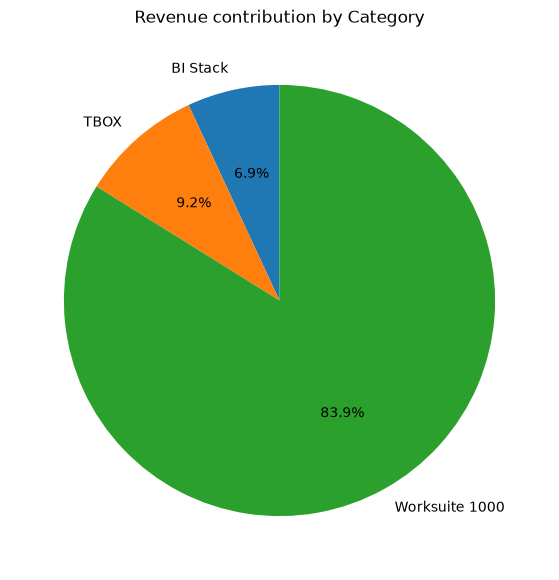

In [90]:
revenue.plot.pie(
    figsize=(7, 7),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue contribution by Category")
plt.ylabel("")
plt.show()

In [91]:
revenue.sum()

np.float64(16269982.17)

In [162]:
# stacked demand by warehouse

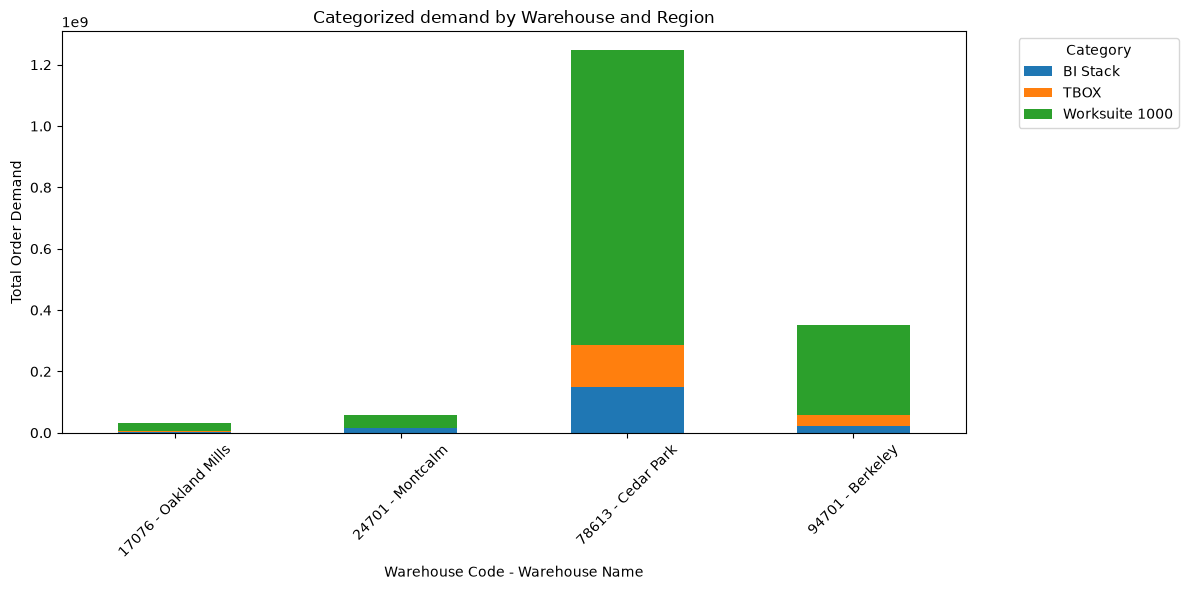

In [192]:
warehouse_category = (
    df.groupby(["WarehouseLabel", "Category"])["Order Demand"]
      .sum()
      .unstack(fill_value=0)
)

warehouse_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Categorized demand by Warehouse and Region")
plt.xlabel("Warehouse Code - Warehouse Name")
plt.ylabel("Total Order Demand")
plt.xticks(rotation=45)
plt.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [193]:
# Worksuite 1000 demand rankings

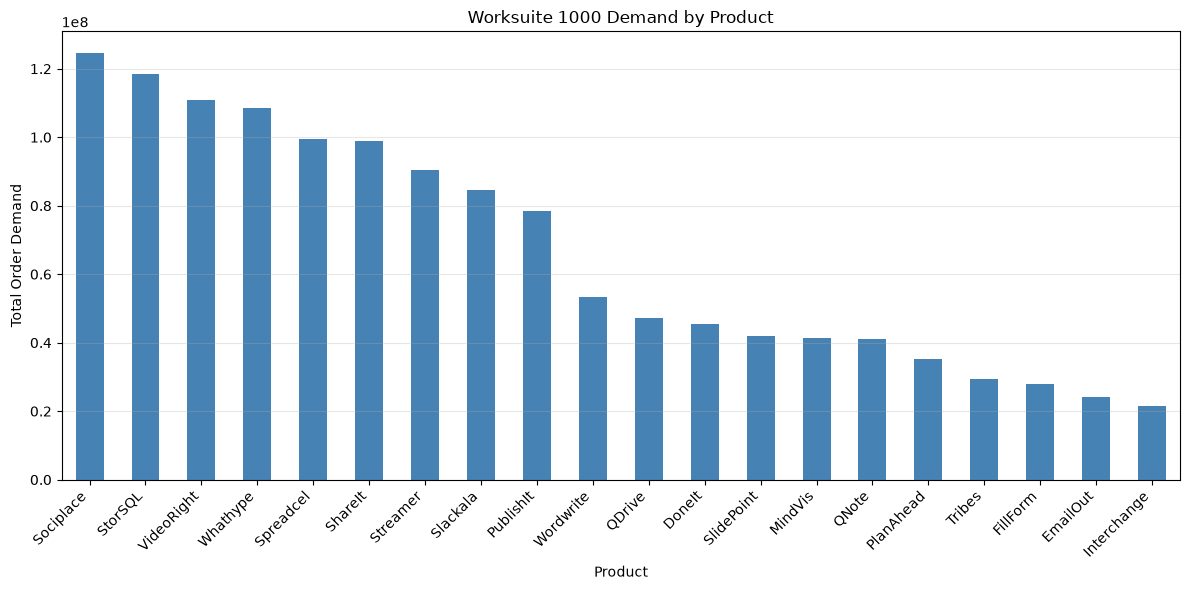

In [196]:
worksuite = df[
    df["Category"].str.strip().str.lower() == "worksuite 1000"
].copy()

product_demand = (
    worksuite.groupby("Product")["Order Demand"]
             .sum()
             .sort_values(ascending=False)
)

product_demand.plot(
    kind="bar",
    figsize=(12, 6),
    color="steelblue"
)

plt.title("Worksuite 1000 Demand by Product")
plt.xlabel("Product")
plt.ylabel("Total Order Demand")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()